In [1]:
import pandas as pd

In [2]:
import os
os.getcwd()

'c:\\Users\\Aswita\\Documents\\TIF\\SEMESTER 4\\REKAYASA & VISUALISASI DATA\\nyc-taxi\\src\\nyc_taxi\\pipeline\\step_02_preprocessing'

In [3]:
yellow_01 = pd.read_parquet('../../../../data/bronze/yellow_tripdata_2025-01.parquet')
yellow_02 = pd.read_parquet('../../../../data/bronze/yellow_tripdata_2025-02.parquet')
yellow_03 = pd.read_parquet('../../../../data/bronze/yellow_tripdata_2025-03.parquet')
yellow_04 = pd.read_parquet('../../../../data/bronze/yellow_tripdata_2025-04.parquet')
yellow_01.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


In [4]:
yellow_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [5]:
# ubah tipe data menjadi timestamp pada semua dataframe yellow
for df in [yellow_01, yellow_02, yellow_03, yellow_04]:
    df['tpep_pickup_datetime'] = df['tpep_pickup_datetime'].astype('timestamp[us][pyarrow]')
    df['tpep_dropoff_datetime'] = df['tpep_dropoff_datetime'].astype('timestamp[us][pyarrow]')

In [6]:
yellow_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype                 
---  ------                 -----                 
 0   VendorID               int32                 
 1   tpep_pickup_datetime   timestamp[us][pyarrow]
 2   tpep_dropoff_datetime  timestamp[us][pyarrow]
 3   passenger_count        float64               
 4   trip_distance          float64               
 5   RatecodeID             float64               
 6   store_and_fwd_flag     object                
 7   PULocationID           int32                 
 8   DOLocationID           int32                 
 9   payment_type           int64                 
 10  fare_amount            float64               
 11  extra                  float64               
 12  mta_tax                float64               
 13  tip_amount             float64               
 14  tolls_amount           float64               
 15  improvement_sur

In [7]:
green_01 = pd.read_parquet('../../../../data/bronze/green_tripdata_2025-01.parquet')
green_02 = pd.read_parquet('../../../../data/bronze/green_tripdata_2025-02.parquet')
green_03 = pd.read_parquet('../../../../data/bronze/green_tripdata_2025-03.parquet')
green_04 = pd.read_parquet('../../../../data/bronze/green_tripdata_2025-04.parquet')
green_01.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,2,2025-01-01 00:03:01,2025-01-01 00:17:12,N,1.0,75,235,1.0,5.93,24.70,...,0.5,6.80,0.00,NaN,1.0,34.00,1.0,1.0,0.00,0.0
1,2,2025-01-01 00:19:59,2025-01-01 00:25:52,N,1.0,166,75,1.0,1.32,8.60,...,0.5,0.00,0.00,NaN,1.0,11.10,2.0,1.0,0.00,0.0
2,2,2025-01-01 00:05:29,2025-01-01 00:07:21,N,5.0,171,73,1.0,0.41,25.55,...,0.0,0.00,0.00,NaN,1.0,26.55,2.0,2.0,0.00,0.0
3,2,2025-01-01 00:52:24,2025-01-01 01:07:52,N,1.0,74,223,1.0,4.12,21.20,...,0.5,6.13,6.94,NaN,1.0,36.77,1.0,1.0,0.00,0.0
4,2,2025-01-01 00:25:05,2025-01-01 01:01:10,N,1.0,66,158,1.0,4.71,33.80,...,0.5,7.81,0.00,NaN,1.0,46.86,1.0,1.0,2.75,0.0


In [8]:
# ubah tipe data menjadi timestamp pada semua dataframe green
for df in [green_01, green_02, green_03, green_04]:
    df['lpep_pickup_datetime'] = df['lpep_pickup_datetime'].astype('timestamp[us][pyarrow]')
    df['lpep_dropoff_datetime'] = df['lpep_dropoff_datetime'].astype('timestamp[us][pyarrow]')

In [9]:
green_04.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52132 entries, 0 to 52131
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype                 
---  ------                 --------------  -----                 
 0   VendorID               52132 non-null  int32                 
 1   lpep_pickup_datetime   52132 non-null  timestamp[us][pyarrow]
 2   lpep_dropoff_datetime  52132 non-null  timestamp[us][pyarrow]
 3   store_and_fwd_flag     48944 non-null  object                
 4   RatecodeID             48944 non-null  float64               
 5   PULocationID           52132 non-null  int32                 
 6   DOLocationID           52132 non-null  int32                 
 7   passenger_count        48944 non-null  float64               
 8   trip_distance          52132 non-null  float64               
 9   fare_amount            52132 non-null  float64               
 10  extra                  52132 non-null  float64               
 11  mta_tax        

In [10]:
# ubah nama kolom menjadi lowercase pada yellow taxi
for df in [yellow_01, yellow_02, yellow_03, yellow_04]:
    df.columns = df.columns.str.lower()
yellow_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype                 
---  ------                 -----                 
 0   vendorid               int32                 
 1   tpep_pickup_datetime   timestamp[us][pyarrow]
 2   tpep_dropoff_datetime  timestamp[us][pyarrow]
 3   passenger_count        float64               
 4   trip_distance          float64               
 5   ratecodeid             float64               
 6   store_and_fwd_flag     object                
 7   pulocationid           int32                 
 8   dolocationid           int32                 
 9   payment_type           int64                 
 10  fare_amount            float64               
 11  extra                  float64               
 12  mta_tax                float64               
 13  tip_amount             float64               
 14  tolls_amount           float64               
 15  improvement_sur

In [11]:
# lowercase untuk green taxi

for df in [green_01, green_02, green_03, green_04]:
    df.columns = df.columns.str.lower()
green_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48326 entries, 0 to 48325
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype                 
---  ------                 --------------  -----                 
 0   vendorid               48326 non-null  int32                 
 1   lpep_pickup_datetime   48326 non-null  timestamp[us][pyarrow]
 2   lpep_dropoff_datetime  48326 non-null  timestamp[us][pyarrow]
 3   store_and_fwd_flag     46490 non-null  object                
 4   ratecodeid             46490 non-null  float64               
 5   pulocationid           48326 non-null  int32                 
 6   dolocationid           48326 non-null  int32                 
 7   passenger_count        46490 non-null  float64               
 8   trip_distance          48326 non-null  float64               
 9   fare_amount            48326 non-null  float64               
 10  extra                  48326 non-null  float64               
 11  mta_tax        

In [12]:
# penambahan kolom trip_duration_min pada dataframe yellow dan green taxi
for df in [yellow_01, yellow_02, yellow_03, yellow_04]:
    df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

for df in[green_01, green_02, green_03, green_04]:
    df['trip_duration_min'] = (df['lpep_dropoff_datetime'] - df['lpep_pickup_datetime']).dt.total_seconds() / 60

In [13]:
yellow_01.head()

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,cbd_congestion_fee,trip_duration_min
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,...,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0,8.35
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,...,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0,2.55
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,...,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0,1.95
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,...,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0,5.566667
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,...,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0,3.533333


In [18]:
yellow_04.isnull().sum()


vendorid                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          745730
trip_distance                 0
ratecodeid               745730
store_and_fwd_flag       745730
pulocationid                  0
dolocationid                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     745730
airport_fee              745730
cbd_congestion_fee            0
trip_duration_min             0
dtype: int64

In [30]:
kondisi1 = yellow_04['passenger_count'].isnull()
kondisi2 = yellow_04['trip_distance'].isnull()
kondisi3 = yellow_04['fare_amount'].isnull()
yellow_04.loc[kondisi1 | kondisi2| kondisi3]

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,cbd_congestion_fee,trip_duration_min


In [36]:
# imputasi nilai null
for df in [yellow_01, yellow_02, yellow_03, yellow_04]:
    df['passenger_count'] = df['passenger_count'].fillna(0)
    df['trip_distance'] = df['trip_distance'].fillna(0)
    df['fare_amount'] = df['fare_amount'].fillna(0)
for df in [green_01, green_02, green_03, green_04]:
    df['passenger_count'] = df['passenger_count'].fillna(0)
    df['trip_distance'] = df['trip_distance'].fillna(0)
    df['fare_amount'] = df['fare_amount'].fillna(0)

In [37]:
kondisi1 = yellow_04['passenger_count']==0
kondisi2 = yellow_04['trip_distance']==0
kondisi3 = yellow_04['fare_amount']==0
yellow_04.loc[kondisi1| kondisi2| kondisi3]

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,cbd_congestion_fee,trip_duration_min
14,1,2025-04-01 00:36:37,2025-04-01 01:05:35,1.0,0.00,1.0,N,68,17,1,...,0.0,0.5,0.0,0.00,1.0,31.00,0.0,0.00,0.00,28.966667
34,2,2025-04-01 00:33:30,2025-04-01 00:33:34,1.0,0.00,1.0,N,68,68,2,...,1.0,0.5,0.0,0.00,1.0,8.75,2.5,0.00,0.75,0.066667
41,1,2025-04-01 00:03:02,2025-04-01 00:38:47,0.0,18.20,2.0,N,132,230,1,...,5.0,0.5,5.0,6.94,1.0,88.44,2.5,1.75,0.75,35.75
74,1,2025-04-01 00:21:30,2025-04-01 00:47:14,1.0,0.00,99.0,N,161,242,1,...,0.0,0.5,0.0,0.00,1.0,36.00,0.0,0.00,0.00,25.733333
98,2,2025-04-01 00:12:32,2025-04-01 00:12:47,1.0,0.00,1.0,N,168,168,1,...,1.0,0.5,38.0,0.00,1.0,43.50,0.0,0.00,0.00,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3970548,2,2025-04-30 23:37:25,2025-05-01 00:06:12,0.0,8.77,NaN,None,48,243,0,...,0.0,0.5,0.0,0.00,1.0,5.07,NaN,NaN,0.75,28.783333
3970549,2,2025-04-30 23:53:37,2025-05-01 00:12:34,0.0,3.20,NaN,None,234,142,0,...,0.0,0.5,0.0,0.00,1.0,25.75,NaN,NaN,0.75,18.95
3970550,2,2025-04-30 23:31:55,2025-04-30 23:46:09,0.0,2.49,NaN,None,68,45,0,...,0.0,0.5,0.0,0.00,1.0,3.81,NaN,NaN,0.75,14.233333
3970551,2,2025-04-30 23:27:36,2025-04-30 23:49:01,0.0,3.23,NaN,None,186,141,0,...,0.0,0.5,0.0,0.00,1.0,25.16,NaN,NaN,0.75,21.416667


In [40]:
# imputasi nilai 0
for df in [yellow_01, yellow_02, yellow_03, yellow_04]:
    median_passenger_count = df['passenger_count'].median()
    df['passenger_count'] = df['passenger_count'].replace(0, median_passenger_count)
    mean_tirp_distance = df['trip_distance'].mean()
    df['trip_distance'] = df['trip_distance'].replace(0, mean_tirp_distance)
    mean_fare_amount = df['fare_amount'].mean()
    df['fare_amount'] = df['fare_amount'].replace(0, mean_fare_amount)
for df in [green_01, green_02, green_03, green_04]:
    median_passenger_count = df['passenger_count'].median()
    df['passenger_count'] = df['passenger_count'].replace(0, median_passenger_count)
    mean_tirp_distance = df['trip_distance'].mean()
    df['trip_distance'] = df['trip_distance'].replace(0, mean_tirp_distance)
    mean_fare_amount = df['fare_amount'].mean()
    df['fare_amount'] = df['fare_amount'].replace(0, mean_fare_amount)

In [44]:
kondisi1 = yellow_04['passenger_count']==0
kondisi2 = yellow_04['trip_distance']==0
kondisi3 = yellow_04['fare_amount']==0
yellow_04.loc[kondisi1| kondisi2| kondisi3]

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,cbd_congestion_fee,trip_duration_min


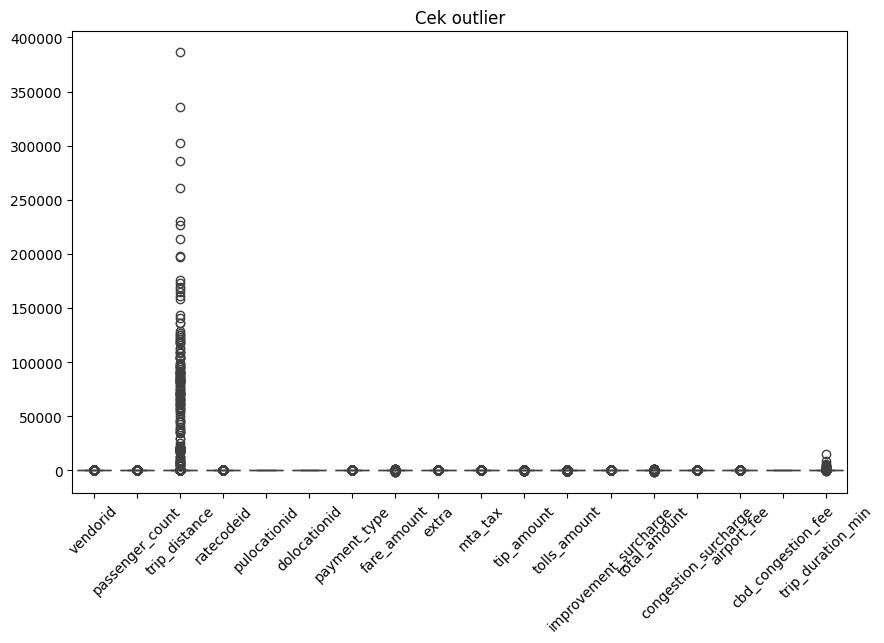

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=yellow_04)
plt.xticks(rotation=45)
plt.title("Cek outlier")
plt.show()



In [45]:
# menghapus data anomali

for df in [yellow_01, yellow_02, yellow_03, yellow_04]:
    df.drop(df[df['trip_duration_min'] <= 0].index, inplace=True)
    df.drop(df[df['trip_distance'] <= 0].index, inplace=True)
    df.drop(df[df['fare_amount'] <= 0].index, inplace=True)

for df in [green_01, green_02, green_03, green_04]:
    df.drop(df[df['trip_duration_min'] <= 0].index, inplace=True)
    df.drop(df[df['trip_distance'] <= 0].index, inplace=True)
    df.drop(df[df['fare_amount'] <= 0].index, inplace=True)

In [51]:
columns_yellow = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'pulocationid', 'dolocationid', 'trip_distance', 'fare_amount', 'tip_amount', 'total_amount', 'passenger_count', 'trip_duration_min']
columns_green = ['lpep_pickup_datetime', 'lpep_dropoff_datetime', 'pulocationid', 'dolocationid', 'trip_distance', 'fare_amount', 'tip_amount', 'total_amount', 'passenger_count', 'trip_duration_min']

yellow_01 = yellow_01[columns_yellow]
yellow_02 = yellow_02[columns_yellow]
yellow_03 = yellow_03[columns_yellow]
yellow_04 = yellow_04[columns_yellow]

green_01 = green_01[columns_green]
green_02 = green_02[columns_green]
green_03 = green_03[columns_green]
green_04 = green_04[columns_green]

In [59]:
# menggabuun dataframe yellow dan green taxi
yellow_taxi = pd.concat([yellow_01, yellow_02, yellow_03, yellow_04], ignore_index=True)
green_taxi = pd.concat([green_01, green_02, green_03, green_04], ignore_index=True)
yellow_taxi.info()
green_taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14382138 entries, 0 to 14382137
Data columns (total 10 columns):
 #   Column                 Dtype                 
---  ------                 -----                 
 0   tpep_pickup_datetime   timestamp[us][pyarrow]
 1   tpep_dropoff_datetime  timestamp[us][pyarrow]
 2   pulocationid           int32                 
 3   dolocationid           int32                 
 4   trip_distance          float64               
 5   fare_amount            float64               
 6   tip_amount             float64               
 7   total_amount           float64               
 8   passenger_count        float64               
 9   trip_duration_min      double[pyarrow]       
dtypes: double[pyarrow](1), float64(5), int32(2), timestamp[us][pyarrow](2)
memory usage: 987.5 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196992 entries, 0 to 196991
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype             

In [65]:
green_taxi.tail()

,lpep_pickup_datetime,lpep_dropoff_datetime,pulocationid,dolocationid,trip_distance,fare_amount,tip_amount,total_amount,passenger_count,trip_duration_min
196987,2025-04-30 19:10:00,2025-04-30 19:51:00,92,74,11.09,36.53,0.00,44.97,1.0,41.0
196988,2025-04-30 19:49:00,2025-04-30 19:58:00,41,166,1.33,13.58,4.52,19.60,1.0,9.0
196989,2025-04-30 20:56:00,2025-04-30 21:12:00,202,233,4.17,28.70,6.74,40.44,1.0,16.0
196990,2025-04-30 20:51:00,2025-04-30 20:59:00,181,25,1.10,15.00,0.00,16.50,1.0,8.0
196991,2025-04-30 21:36:00,2025-04-30 22:10:00,82,258,6.52,30.36,0.00,31.86,1.0,34.0


In [ ]:
# load cleaned data ke skema silver
import os
os.makedirs('../../../../data/silver', exist_ok=True)
yellow_taxi.to_parquet('../../../../data/silver/yellow_trips', index=False)
green_taxi.to_parquet('../../../../data/silver/green_trips', index=False)

import duckdb
con = duckdb.connect(database='../../../../data/silver/nyc_taxi.duckdb', read_only=False)
con.execute("CREATE SCHEMA IF NOT EXISTS silver")
con.execute("CREATE OR REPLACE TABLE silver.yellow_trips AS SELECT * FROM read_parquet('../../../../data/silver/yellow_trips')")
con.execute("CREATE OR REPLACE TABLE silver.green_trips AS SELECT * FROM read_parquet('../../../../data/silver/green_trips')")

In [72]:
from nyc_taxi.pipeline.step_01_ingestion.weather import ingest_weather_data
ingest_weather_data()

13:30:10.179 | INFO    | prefect - Starting temporary server on http://127.0.0.1:8041
See https://docs.prefect.io/v3/concepts/server#how-to-guides for more information on running a dedicated Prefect server.

13:30:16.982 | INFO    | Flow run 'amiable-phoenix' - Beginning flow run 'amiable-phoenix' for flow 'Ingest Weather Data'

13:30:17.306 | INFO    | Task run 'Fetch Weather Data-38f' - 📡 Fetching weather data from https://archive-api.open-meteo.com/v1/archive with params: {'latitude': 40.7128, 'longitude': -74.006, 'start_date': '2025-01-01', 'end_date': '2025-04-30', 'daily': 'temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,weathercode', 'timezone': 'America/New_York'}

13:30:18.480 | INFO    | Task run 'Fetch Weather Data-38f' - Finished in state Completed()

13:30:18.515 | INFO    | Task run 'Transform Weather Data-476' - ✅ Weather data transformed into DataFrame with 120 records.

13:30:18.519 | INFO    | Task run 'Transform Weather Data-476' - Finished in state Completed()

13:30:18.622 | INFO    | Task run 'Save Weather Data to DuckDB-873' - ✅ Weather data saved to DuckDB successfully.

13:30:18.626 | INFO    | Task run 'Save Weather Data to DuckDB-873' - Finished in state Completed()

13:30:19.304 | INFO    | Flow run 'amiable-phoenix' - Finished in state Completed()